In [77]:
import json
import re
from collections import defaultdict
from difflib import SequenceMatcher
import string
from tqdm.auto import tqdm

In [82]:
# Load datasets accordingly to the subtask

# Select which file we should be working on
file_to_load = "../data/SOMD 2026/subtask 2/noisy_data/left_noise/left_noise_1.0_train_data_subtask_2.jsonl"
with open(file_to_load, 'r') as f:
    train_data = [json.loads(l) for l in list(f)]

with open("../data/SOMD 2026/subtask 2/train_labels.json", "r") as f:
    train_labels = json.load(f)

In [79]:
class SoftwareCoreferenceBaseline:

    """ 
    Fuzzy String Match Baseline method for software mention coreference resolution.
    """

    def __init__(self, mentions_data):

        """
        mentions_data = test_data (data used for inference)
        """
        
        self.mentions = mentions_data


    def _string_similarity(self, s1, s2):
        
        """
        Calculate string similarity between two strings s1 and s2 using SequenceMatcher (we can use any other metrics, like the Levenshtein distance etc.)
        """
        
        return SequenceMatcher(None, s1, s2).ratio()
    
        
    def normalize_mention(self, mention_text, remove_version=True):
        
        """ 
        Function to perform some text processing on the mentions. 
        """
        
        # Lowercase
        text = mention_text.lower()
        
        # Remove software version numbers
        if remove_version:
            text = re.sub(r'\s*v\.?\s*\d+[\w\.-]*', '', text)
            text = re.sub(r'\s+\d+\.\d+[\w\.-]*$', '', text)
        
        # Remove punctuations
        text = text.translate(str.maketrans('', '', string.punctuation))
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def fuzzy_matching(self, threshold = 0.85, remove_version = True):
        """
        Fuzzy string matching with normalized mentions.
        
        Args: - threshold value : Similarity threshold (0-1). We set by defalut to 0.85 (we can use other values)
              - remove_version: Whether to remove version info before matching
        
        Returns clusters as list of lists of mention_ids.
        """
        
        
        # We first normalize all mentions
        normalized_mentions = []
        for mention_obj in self.mentions:
            norm_text = self.normalize_mention(mention_obj['mention'], remove_version)
            normalized_mentions.append({
                'mention_id': mention_obj['mention_id'],
                'normalized': norm_text,
                'original': mention_obj['mention']
            })
        
        # Build clusters
        clusters = []
        used = set()
        
        for i, mention1 in enumerate(normalized_mentions):
            if mention1['mention_id'] in used:
                continue
            
            # Start a new cluster
            cluster = [mention1['mention_id']]
            used.add(mention1['mention_id'])
            
            # Find similar mentions
            for j, mention2 in enumerate(normalized_mentions):

                if i != j and mention2['mention_id'] not in used:
                    similarity = self._string_similarity(mention1['normalized'], mention2['normalized'])
                    
                    # If the similarity is higher than the threshold value, let's add them in the same cluster
                    if similarity >= threshold:
                        cluster.append(mention2['mention_id'])
                        used.add(mention2['mention_id'])
            
            clusters.append(cluster)
        
        return clusters
    
    
    
    def predict(self, fuzzy_threshold = 0.85):
        
        """
        Function to predict clusters. There is a two-stage approach: First, an exact matching, then fuzzy matching.        

        """
        
        # Etape 1 : Exact matching on normalized mentions
        clusters_dict = defaultdict(list)
        
        for mention_obj in self.mentions:
            key = self.normalize_mention(mention_obj['mention'])
            clusters_dict[key].append(mention_obj['mention_id'])
        
        # Etape 2: Fuzzy matching between cluster representatives
        cluster_keys = list(clusters_dict.keys())
        cluster_mapping = {}  # Maps cluster key to final cluster id
        final_clusters = []
        next_cluster_id = 0
        
        for i, key1 in enumerate(cluster_keys):
            
            if key1 in cluster_mapping:
                continue
            
            # Start new cluster
            cluster_mapping[key1] = next_cluster_id
            merged_mentions = clusters_dict[key1].copy()
            
            # Find similar clusters
            for key2 in cluster_keys[i+1:]:
                if key2 not in cluster_mapping:
                    similarity = self._string_similarity(key1, key2)
                    if similarity >= fuzzy_threshold:
                        cluster_mapping[key2] = next_cluster_id
                        merged_mentions.extend(clusters_dict[key2])
            
            final_clusters.append(merged_mentions)
            next_cluster_id += 1
        
        return final_clusters
    
    

In [15]:
#!pip install ipywidgets

In [ ]:
# from corefeval import get_metrics
# coref_resolver = SoftwareCoreferenceBaseline(train_data)
# predicted_clusters = coref_resolver.predict(fuzzy_threshold = 0.67)
# scores = get_metrics(predicted_clusters, train_labels, verbose=False)
# scores[0]

np.float64(0.4786961248425839)

In [80]:
# Chapter2: Evolution of the F1 score vs. threshold level
import numpy as np
from corefeval import get_metrics
thresholds = np.linspace(0, 1, 10)


#Scores per threshold
b_cubed_pt = []
ceafe_pt = []
muc_pt = []
conll_pt = []


coref_resolver = SoftwareCoreferenceBaseline(train_data)
for threshold in tqdm(thresholds):
    predicted_clusters = coref_resolver.predict(fuzzy_threshold = threshold)
    scores = get_metrics(predicted_clusters, train_labels, verbose=False)
    b_cubed_pt.append(scores[1]["b_cubed"]["f1"])
    ceafe_pt.append(scores[1]["ceafe"]["f1"])
    muc_pt.append(scores[1]["muc"]["f1"])
    conll_pt.append(scores[0])

  0%|          | 0/10 [00:00<?, ?it/s]

In [54]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [55]:
best_threshold = thresholds[np.argmax(conll_pt)]
#max_b_cubed = np.max(b_cubed_pt)
#max_ceafe = np.max(ceafe_pt)
#max_muc = np.max(muc_pt)

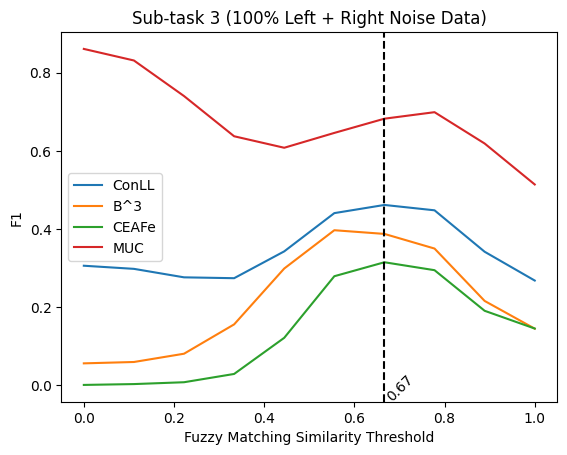

In [ ]:
import matplotlib.pyplot as plt
plt.title("Sub-task 2 (100% Left Noise Data)")
plt.plot(thresholds, conll_pt, label = "ConLL")
plt.plot(thresholds, b_cubed_pt, label = "B^3")
plt.plot(thresholds, ceafe_pt, label ="CEAFe")
plt.plot(thresholds, muc_pt, label = "MUC")
plt.axvline(x = best_threshold, color = 'black', linestyle = "--")
plt.xlabel("Fuzzy Matching Similarity Threshold")
plt.ylabel("F1")
# Set custom tick locations and labels
plt.text(best_threshold, -0.04, f"{best_threshold:.2f}", rotation = 45)
plt.legend()
plt.show()

In [ ]:
plt.savefig("../../SOMD-2026/figures/fuzzy-threshold-subtask-2")